# Land-use map: raw vs. smoothed

Reassembling `distributed_inference.py`'s per-tile predictions into a full 2D map (30x171 tiles from the demo run), and comparing the raw classification against a 3x3 majority-filtered version -- unifying tiles into coherent regions instead of treating each one as an independent decision.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

MAPS_DIR = Path("../data/outputs/land_use_maps")
grid = np.load(MAPS_DIR / "land_use_grid.npy", allow_pickle=True)
smoothed = np.load(MAPS_DIR / "land_use_grid_smoothed.npy", allow_pickle=True)

with open("../data/eurosat_stats.json") as f:
    classes = json.load(f)["classes"]
class_to_idx = {c: i for i, c in enumerate(classes)}
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
cmap = ListedColormap(colors)

print(f"Grid shape: {grid.shape}")
changed = (grid != smoothed).sum()
print(f"{changed} / {grid.size} tiles changed by smoothing ({changed / grid.size:.1%})")

# The full grid is a 30x171 strip -- way too elongated to read tile detail at
# a glance. Rather than stretching the display (distorts square tiles into
# rectangles), crop a square NxN block instead: same number of columns as
# rows, centered on the urban area explored in earlier notebooks.
N = grid.shape[0]
COL_START = 75
grid = grid[:, COL_START : COL_START + N]
smoothed = smoothed[:, COL_START : COL_START + N]
print(f"Cropped to {grid.shape} (columns {COL_START}:{COL_START + N})")

Grid shape: (30, 171)
1040 / 5130 tiles changed by smoothing (20.3%)
Cropped to (30, 30) (columns 75:105)


In [2]:
from pathlib import Path

TILES_DIR = Path("../data/outputs/sentinel2_tiles")
TILE_SIZE = 64
n_rows, n_cols = grid.shape


def stretch(band, low=2, high=98):
    lo, hi = np.percentile(band, [low, high])
    return np.clip((band.astype(np.float32) - lo) / (hi - lo), 0, 1)


composite = np.zeros((n_rows * TILE_SIZE, n_cols * TILE_SIZE, 3), dtype=np.float32)
for i in range(n_rows):
    for j in range(n_cols):
        tile = np.load(TILES_DIR / f"tile_{i:03d}_{j + COL_START:03d}.npy")
        composite[i * TILE_SIZE : (i + 1) * TILE_SIZE, j * TILE_SIZE : (j + 1) * TILE_SIZE, :] = tile

# Stretched globally (once, on the whole composite) rather than per-tile --
# keeps the imagery visually consistent across the whole map.
composite_stretched = np.stack([stretch(composite[..., c]) for c in range(3)], axis=-1)
print(f"Composite shape: {composite_stretched.shape}")

Composite shape: (1920, 1920, 3)


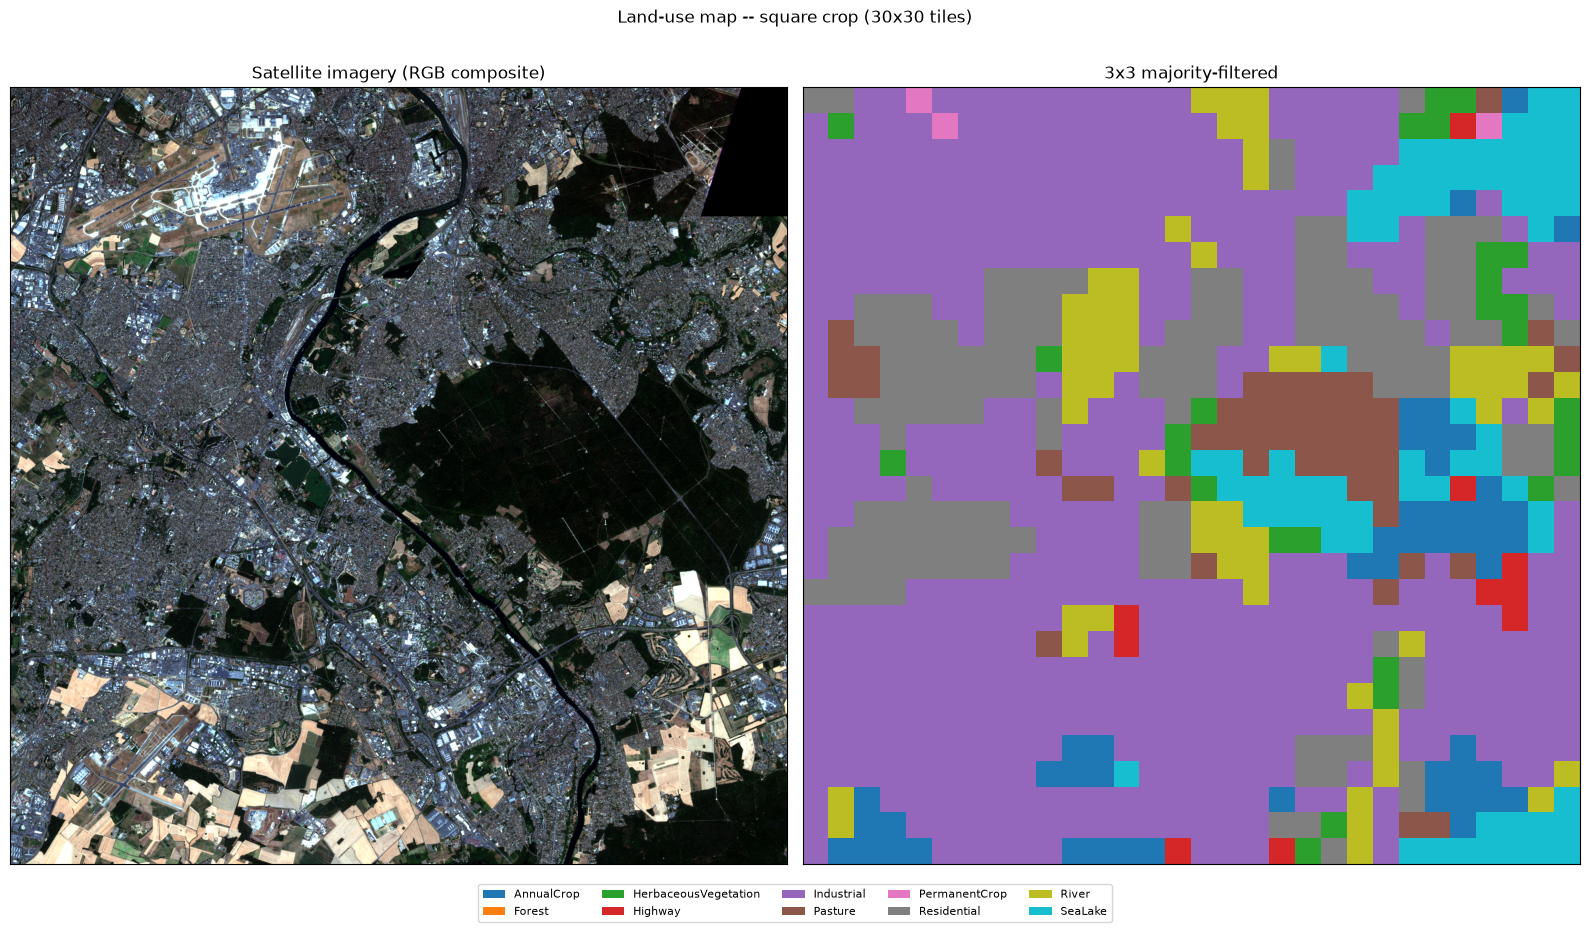

In [3]:
def to_index_map(grid):
    idx_map = np.zeros(grid.shape, dtype=int)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            idx_map[i, j] = class_to_idx[grid[i, j]]
    return idx_map


fig, (ax_rgb, ax_smoothed) = plt.subplots(1, 2, figsize=(16, 9))

ax_rgb.imshow(composite_stretched)
ax_rgb.set_title("Satellite imagery (RGB composite)")
ax_rgb.set_xticks([])
ax_rgb.set_yticks([])

ax_smoothed.imshow(to_index_map(smoothed), cmap=cmap, vmin=0, vmax=len(classes) - 1)
ax_smoothed.set_title("3x3 majority-filtered")
ax_smoothed.set_xticks([])
ax_smoothed.set_yticks([])

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], label=classes[i])
    for i in range(len(classes))
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f"Land-use map -- square crop ({grid.shape[0]}x{grid.shape[1]} tiles)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## YOLO-style region detection

A wall-to-wall colored grid (above) doesn't translate directly to YOLO-style box+label annotations -- YOLO labels individual, well-separated *objects*, while every tile here has a classification, so a box+label per tile would just be hundreds of overlapping labels.

Adapted version: find contiguous regions of the same class (connected-component labeling on the smoothed grid), then draw one bounding box + one label per *region* instead of per tile -- same idea as YOLO, applied to zones rather than individual cells. Small regions (probably residual noise) are skipped, similar to a confidence threshold.

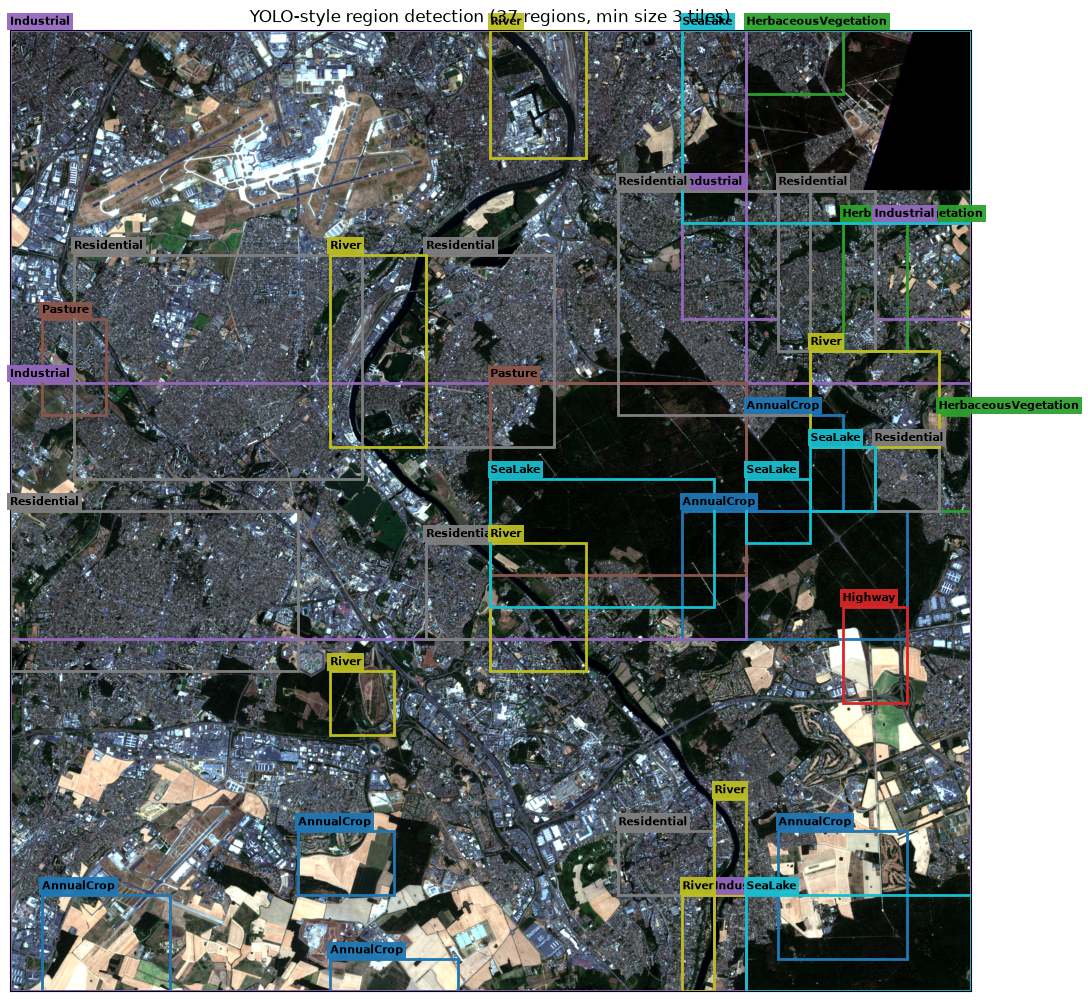

In [4]:
from scipy import ndimage

MIN_REGION_SIZE = 3  # tiles; smaller regions are skipped as likely noise

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(composite_stretched)

n_regions_drawn = 0
for class_idx, class_name in enumerate(classes):
    mask = smoothed == class_name
    if not mask.any():
        continue

    labeled, n_components = ndimage.label(mask)
    for region_id in range(1, n_components + 1):
        region_mask = labeled == region_id
        if region_mask.sum() < MIN_REGION_SIZE:
            continue

        rows, cols = np.where(region_mask)
        r0, r1 = rows.min(), rows.max() + 1
        c0, c1 = cols.min(), cols.max() + 1
        color = colors[class_idx]

        rect = plt.Rectangle(
            (c0 * TILE_SIZE, r0 * TILE_SIZE),
            (c1 - c0) * TILE_SIZE, (r1 - r0) * TILE_SIZE,
            linewidth=2, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            c0 * TILE_SIZE, r0 * TILE_SIZE - 6, class_name,
            fontsize=8, color="black", weight="bold", va="bottom",
            bbox=dict(facecolor=color, edgecolor="none", pad=2, alpha=0.95),
        )
        n_regions_drawn += 1

ax.set_title(f"YOLO-style region detection ({n_regions_drawn} regions, min size {MIN_REGION_SIZE} tiles)")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0, smoothed.shape[1] * TILE_SIZE)
ax.set_ylim(smoothed.shape[0] * TILE_SIZE, 0)
plt.tight_layout()
plt.show()